In [88]:
# first quick look at the data from test monolith run

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [2]:
overDF = pd.read_csv('./output/monolithTestDOS7.CSV')

noMagDF = pd.read_csv('./noMagFull/noMagFullDOS.CSV')

In [3]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
# overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [4]:
noMagDF['sensor'] = pd.to_numeric(noMagDF['sensor'], errors='coerce')
# noMagDF['sensor']

noMagDF['seconds'] = pd.to_numeric(noMagDF['seconds'], errors='coerce')

In [5]:
overDF.dropna(subset=['sensor']).reset_index(drop=True)
noMagDF.dropna(subset=['sensor']).reset_index(drop=True)

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260413_220248_000,79368.000,0.0000,NaN,0.0000,NaN,8228
1,260413_220248_458,79368.461,0.0000,NaN,0.0000,NaN,8174
2,260413_220248_557,79368.555,0.0000,NaN,0.0000,NaN,8187
3,260413_220248_657,79368.656,0.0000,NaN,0.0000,NaN,8182
4,260413_220248_757,79368.758,0.0000,NaN,0.0000,NaN,8146
...,...,...,...,...,...,...,...
41907,260413_231245_500,83565.500,4159.9492,N,8739.4629,W,8284
41908,260413_231245_600,83565.602,4159.9492,N,8739.4629,W,8265
41909,260413_231245_700,83565.703,4159.9492,N,8739.4629,W,8246
41910,260413_231245_800,83565.797,4159.9492,N,8739.4629,W,8226


In [6]:
noMagSens = noMagDF['sensor'].to_numpy(dtype=float)
noMagSens = noMagSens[1000:-1000]
noMagVolt = noMagSens * 5 / 16383
noMagSecs = noMagDF['seconds'].to_numpy(dtype=float)
noMagSecs = noMagSecs[1000:-1000]

In [7]:
overSens = np.array(overDF['sensor'])
overSens = overSens[1000:-1000]

overSecs = np.array(overDF['seconds'])
overSecs = overSecs[1000:-1000]

In [8]:
overVolt = overSens * 5 / 16383

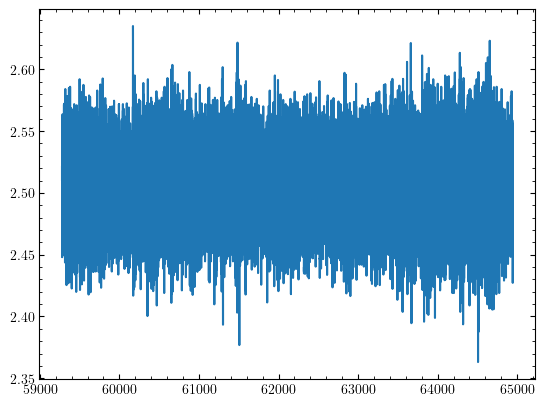

In [9]:
plt.plot(overSecs,overVolt)

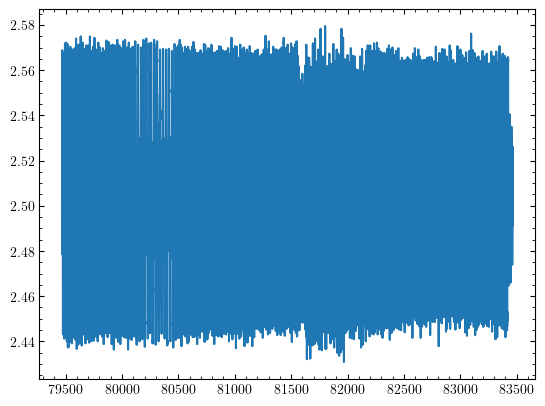

In [10]:
plt.plot(noMagSecs,noMagVolt)
# plt.xlim(81550,81700)

In [11]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

In [12]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=300)

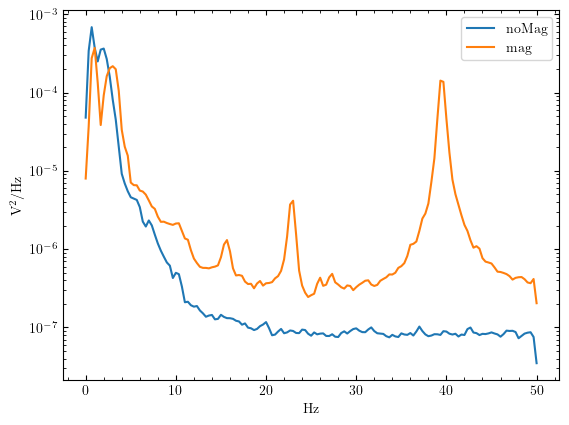

In [13]:
plt.plot(noMagF,noMagPSD,label='noMag')
plt.plot(overF,overPSD,label='mag')
plt.legend()
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.semilogy()
plt.show()

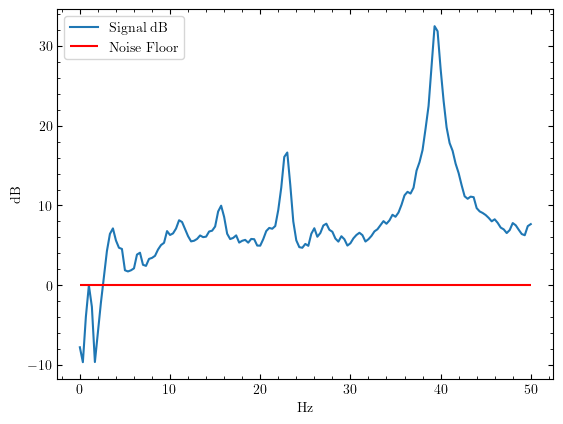

In [14]:
plt.plot(overF,10*np.log10(overPSD/noMagPSD),label='Signal dB')
plt.ylabel('dB')
plt.xlabel('Hz')
plt.hlines(0,0,50,colors='red',label='Noise Floor')
plt.legend()
plt.show()

In [104]:
# shortOverSecs = overSecs[3000:6000]
# shortOverVolt = overVolt[3000:6000]

# shortNoMagSecs = noMagSecs[3000:6000]
# shortNoMagVolt = noMagVolt[3000:6000]

In [105]:
# plt.plot(shortOverSecs,shortOverVolt)

In [106]:
# plt.plot(shortNoMagSecs,shortNoMagVolt)

In [107]:
# shortOverF,shortOverPSD = sp.signal.welch(shortOverVolt,fs=100,nperseg=200)
# shortNoMagF,shortNoMagPSD = sp.signal.welch(shortNoMagVolt,fs=100,nperseg=200)

In [108]:
# plt.plot(shortOverF,shortOverPSD,label='mono')
# plt.plot(shortNoMagF,shortNoMagPSD,label='noMag')
# plt.legend()

In [109]:
# plt.plot(shortOverF,np.log10(shortOverPSD/shortNoMagPSD))
# plt.hlines(0,0,50)